Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, ConcatDataset, random_split
from torchvision import datasets, transforms, models

from helper import make_dataset, train, test, get_indices
import matplotlib.pyplot as plt
import numpy as np

Use device

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


Fill in respective folder location for dataset

In [3]:
import torch
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  
    transforms.RandomRotation(5),      
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_real_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\train\real"
train_fake_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\train\fake"
valid_real_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\valid\real"
valid_fake_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\valid\fake"

train_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\train"
valid_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\valid"

Create train, valid and test datasets and dataloaders

In [4]:

train_dataset = make_dataset(train_dir, 9500, 500, transform)

valid_dataset = make_dataset(valid_dir, 950, 50, transform)

val_size = int(0.5 * len(valid_dataset))
test_size = len(valid_dataset) - val_size

val_dataset, test_dataset = random_split(valid_dataset, [val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

real_count = 0
fake_count = 0

for _, labels in train_loader:
    real_count += (labels == 0).sum().item()
    fake_count += (labels == 1).sum().item()

print("Train real:", real_count)
print("Train fake:", fake_count)



Train real: 9500
Train fake: 500


ResNet18

In [5]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Sequential(
    nn.Linear(512, 128),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(128, 32),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(32, 2),
)
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer2.parameters():
    param.requires_grad = True

In [6]:
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0,19.0]).to(device))
model = model.to(device)
optimizer = optim.Adam([
    {'params': model.layer3.parameters(), 'lr': 1e-5, 'weight_decay': 1e-4},
    {'params': model.layer4.parameters(), 'lr': 1e-5, 'weight_decay': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-4, 'weight_decay': 1e-4}
])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5)
loss_values, thresholds = train(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=20, scheduler=scheduler)
best_epoch_idx = thresholds.index(max(thresholds, key=lambda t: t))  # or manually note it
best_threshold = thresholds[best_epoch_idx]
# test(model, test_loader, device, threshold=best_threshold)


Epoch : 0
Optimal Threshold : 0.4585
Train Loss        : 0.6875
F1 Score          : 0.1875
Recall            : 0.2143  <- how many anomalies caught
Precision         : 0.1667
AUC-ROC           : 0.6195
PR-AUC            : 0.1478

Confusion Matrix:
                   Predicted Real  Predicted Fake
Actual Real        442             30
Actual Fake        22              6

Epoch : 1
Optimal Threshold : 0.4547
Train Loss        : 0.6719
F1 Score          : 0.1965
Recall            : 0.6071  <- how many anomalies caught
Precision         : 0.1172
AUC-ROC           : 0.7352
PR-AUC            : 0.1499

Confusion Matrix:
                   Predicted Real  Predicted Fake
Actual Real        344             128
Actual Fake        11              17

Epoch : 2
Optimal Threshold : 0.4914
Train Loss        : 0.6384
F1 Score          : 0.4179
Recall            : 0.5000  <- how many anomalies caught
Precision         : 0.3590
AUC-ROC           : 0.8264
PR-AUC            : 0.3536

Confusion Matrix:
 

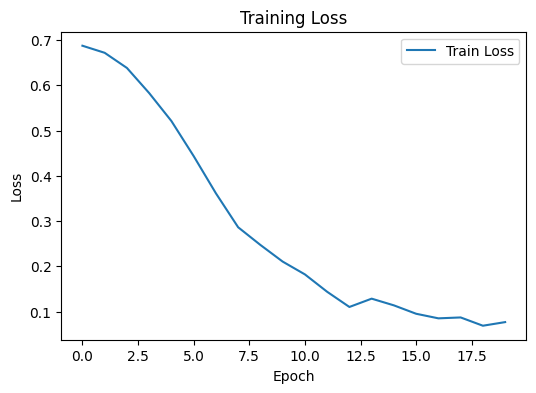

C:\Users\thoai\AppData\Local\Temp\ipykernel_32060\2632336927.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


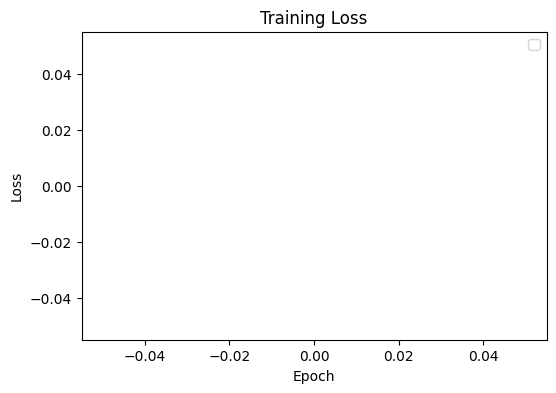

In [8]:
# Remove the accuracy plot, just plot loss
plt.figure(figsize=(6, 4))
plt.plot(loss_values, label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('training_loss.png')
plt.show()

# Remove the accuracy plot, just plot loss
plt.figure(figsize=(6, 4))
plt.plot(label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('training_loss.png')
plt.show()

C:\Users\thoai\AppData\Local\Temp\ipykernel_32060\1368614117.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))



TEST SET RESULTS (Threshold: 0.4577)
F1 Score          : 0.4810
Recall            : 0.8636  <- how many anomalies caught
Precision         : 0.3333
AUC-ROC           : 0.9339
PR-AUC            : 0.7540

Confusion Matrix:
                   Predicted Real  Predicted Fake
Actual Real        440             38
Actual Fake        3               19


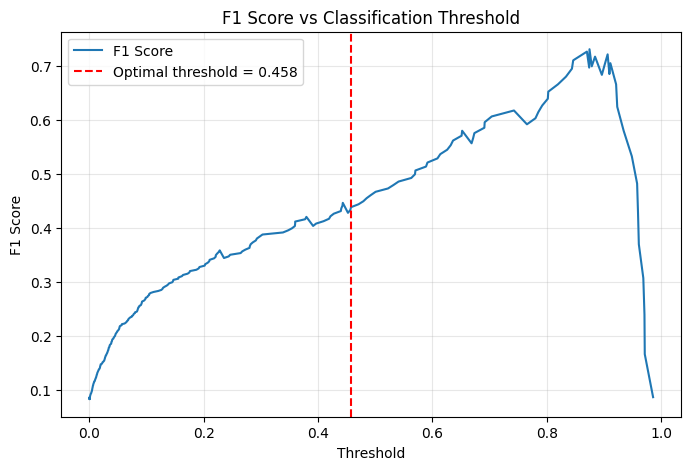

In [9]:
from sklearn.metrics import average_precision_score

# Load best model
model.load_state_dict(torch.load('best_model.pth'))

best_threshold = thresholds[-1]  # or manually pick the best epoch's threshold
test(model, test_loader, device, threshold=best_threshold)

# Cell 8: NEW - Threshold vs F1 plot
all_labels = []
all_probs = []

model.eval()
for images, labels in test_loader:
    images = images.to(device)
    labels = labels.long().to(device)
    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
    all_labels.extend(labels.cpu().numpy())
    all_probs.extend(probs[:, 1].cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds_curve = precision_recall_curve(all_labels, all_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

plt.figure(figsize=(8, 5))
plt.plot(thresholds_curve, f1_scores[:-1], label='F1 Score')
plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Optimal threshold = {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Classification Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('threshold_vs_f1.png', dpi=150)
plt.show()